<h1>Detection model<h1>

<h2>Inspect<h2>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
from PIL import Image

DATA_PATH = Path(
    "/content/drive/MyDrive/oilspill_detect.ai/classification/kaggle/data"
)

for class_name in ["Class_0", "Class_1"]:
    folder = DATA_PATH / class_name
    files = [f for f in folder.iterdir() if f.is_file()]

    print(f"\n{class_name}")
    print("-" * 30)
    print("Number of files:", len(files))

    # Inspect first image
    img_path = files[0]
    img = Image.open(img_path)

    print("Example file:", img_path.name)
    print("Format:", img.format)
    print("Size:", img.size)
    print("Mode:", img.mode)
    print("Pixel dtype:", __import__("numpy").array(img).dtype)
    print("Pixel range:", __import__("numpy").array(img).min(),
          "to", __import__("numpy").array(img).max())


Class_0
------------------------------
Number of files: 3695
Example file: class_0_02708.jpg
Format: JPEG
Size: (400, 400)
Mode: RGB
Pixel dtype: uint8
Pixel range: 1 to 238

Class_1
------------------------------
Number of files: 1853
Example file: class_1_00796.jpg
Format: JPEG
Size: (400, 400)
Mode: RGB
Pixel dtype: uint8
Pixel range: 0 to 146


<h2>Preprocessing<h2>

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/oilspill_detect.ai/classification/kaggle/data"

classes = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

print("Classes:", classes)

for cls in classes:
    path = os.path.join(DATASET_PATH, cls)
    print(f"{cls}: {len(os.listdir(path))} files")

Classes: ['Class_0', 'Class_1', 'sample']
Class_0: 3695 files
Class_1: 1853 files
sample: 2 files


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/oilspill_detect.ai/classification/kaggle/data"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

CLASS_NAMES = ["Class_0", "Class_1"]

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    class_names=CLASS_NAMES,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    class_names=CLASS_NAMES,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

print("Classes:", train_ds.class_names)

Found 5548 files belonging to 2 classes.
Using 3884 files for training.
Found 5548 files belonging to 2 classes.
Using 1664 files for validation.
Classes: ['Class_0', 'Class_1']


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_test_ds = val_test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

print("Normalization completed.")

Normalization completed.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_test_ds = val_test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset pipeline optimized.")

Dataset pipeline optimized.


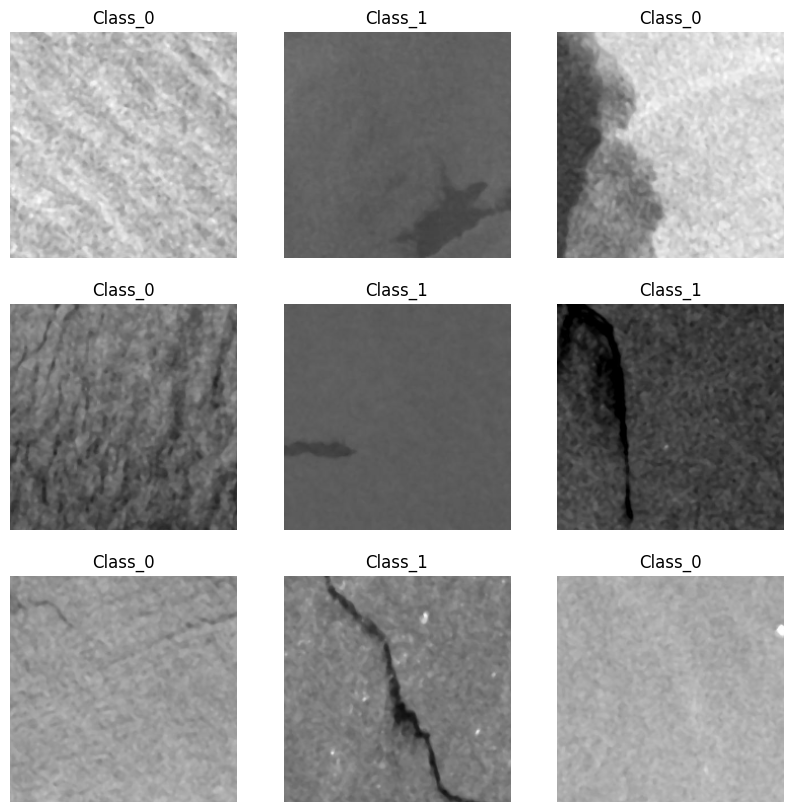

In [ ]:
import matplotlib.pyplot as plt

class_names = ["Class_0", "Class_1"]

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

print("Data augmentation applied to training dataset.")

Data augmentation applied to training dataset.


<h2>Training<h2>

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = tf.keras.Sequential([
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_oilspill_classifier.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_test_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
122/122 ━━━━━━━━━━━━━━━━━━━━ 89s 651ms/step - accuracy: 0.7657 - loss: 0.4946 - precision: 0.7293 - recall: 0.4797 - val_accuracy: 0.8498 - val_loss: 0.3793 - val_precision: 0.7443 - val_recall: 0.8309
Epoch 2/15
122/122 ━━━━━━━━━━━━━━━━━━━━ 41s 331ms/step - accuracy: 0.8512 - loss: 0.3716 - precision: 0.8443 - recall: 0.6823 - val_accuracy: 0.8744 - val_loss: 0.3296 - val_precision: 0.7895 - val_recall: 0.8455
Epoch 3/15
122/122 ━━━━━━━━━━━━━━━━━━━━ 41s 332ms/step - accuracy: 0.8731 - loss: 0.3406 - precision: 0.8675 - recall: 0.7337 - val_accuracy: 0.8918 - val_loss: 0.3037 - val_precision: 0.8327 - val_recall: 0.8418
Epoch 4/15
122/122 ━━━━━━━━━━━━━━━━━━━━ 42s 345ms/step - accuracy: 0.8800 - loss: 0.3136 - precision: 0.8794 - recall: 0.7444 - val_accuracy: 0.8984 - val_loss: 0.2973 - val_precision: 0.8360 - val_recall: 0.8618
Epoch 5/15
122/122 ━━━━━━━━━━━━━━━━━━━━ 40s 322ms/step - accuracy: 0.8854 - loss: 0.2997 - precision: 0.8817 - recall: 0.7606 - val_accuracy: 0.8966

In [ ]:
import os

os.makedirs('/content/drive/MyDrive/MARIS', exist_ok=True)
model.save('/content/drive/MyDrive/MARIS/oil_spill_model.keras')

In [ ]:
import os

print(os.path.exists('/content/drive/MyDrive/MARIS/oil_spill_model.keras'))

True


<h2>Evaluating<h2>

In [ ]:
results = model.evaluate(val_test_ds, verbose=1)

print("\nEvaluation Results:")
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9135 - loss: 0.2558 - precision: 0.8745 - recall: 0.8618

Evaluation Results:
loss: 0.2558
compile_metrics: 0.9135


In [ ]:
import os

for root, dirs, files in os.walk('/content'):
    if os.path.basename(root) == 'kaggle':
        print("Kaggle folder found at:")
        print(root)

Kaggle folder found at:
/content/drive/MyDrive/oilspill_detect.ai/classification/kaggle
Kaggle folder found at:
/content/drive/.Encrypted/MyDrive/oilspill_detect.ai/classification/kaggle


In [ ]:
kaggle_path = "/content/drive/MyDrive/oilspill_detect.ai/classification/kaggle"
import os

sample_path = os.path.join(kaggle_path, "data", "sample")

print("Sample path:", sample_path)
print("Contents:", os.listdir(sample_path))

Sample path: /content/drive/MyDrive/oilspill_detect.ai/classification/kaggle/data/sample
Contents: ['Class_1', 'Class_0']


In [ ]:

from tensorflow.keras.utils import load_img, img_to_array

sample_path = "/content/drive/MyDrive/oilspill_detect.ai/classification/kaggle/data/sample"

# Model input size
IMG_SIZE = (224, 224)

# Go through Class_0 and Class_1
for class_name in ["Class_0", "Class_1"]:

    class_path = os.path.join(sample_path, class_name)

    print(f"\n===== {class_name} =====")

    for filename in os.listdir(class_path):

        if filename.lower().endswith((".jpg", ".jpeg", ".png")):

            image_path = os.path.join(class_path, filename)

            # Load image
            img = load_img(image_path, target_size=IMG_SIZE)

            # Convert to array
            img_array = img_to_array(img)

            # Rescale exactly like training
            img_array = img_array / 255.0

            # Add batch dimension
            img_array = np.expand_dims(img_array, axis=0)

            # Prediction
            prediction = model.predict(img_array, verbose=0)[0][0]

            # Assuming Class_0 = no oil spill, Class_1 = oil spill
            predicted_class = "Class_1 (Oil Spill)" if prediction >= 0.5 else "Class_0 (No Oil Spill)"

            confidence = prediction if prediction >= 0.5 else 1 - prediction

            print(f"{filename}")
            print(f"Prediction: {predicted_class}")
            print(f"Confidence: {confidence:.2%}")
            print()


===== Class_0 =====
class_0_00005.jpg
Prediction: Class_0 (No Oil Spill)
Confidence: 73.65%

class_0_00004.jpg
Prediction: Class_0 (No Oil Spill)
Confidence: 73.22%

class_0_00002.jpg
Prediction: Class_1 (Oil Spill)
Confidence: 89.43%

class_0_00003.jpg
Prediction: Class_0 (No Oil Spill)
Confidence: 96.53%

class_0_00001.jpg
Prediction: Class_0 (No Oil Spill)
Confidence: 98.49%


===== Class_1 =====
class_1_00005.jpg
Prediction: Class_1 (Oil Spill)
Confidence: 53.24%

class_1_00002.jpg
Prediction: Class_0 (No Oil Spill)
Confidence: 82.61%

class_1_00004.jpg
Prediction: Class_1 (Oil Spill)
Confidence: 98.71%

class_1_00001.jpg
Prediction: Class_1 (Oil Spill)
Confidence: 85.49%

class_1_00003.jpg
Prediction: Class_1 (Oil Spill)
Confidence: 61.40%



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions.ravel() >= 0.5).astype(int))

print(classification_report(
    y_true,
    y_pred,
    target_names=["Class_0", "Class_1"]
))

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

              precision    recall  f1-score   support

     Class_0       0.93      0.94      0.94      1114
     Class_1       0.87      0.86      0.87       550

    accuracy                           0.91      1664
   macro avg       0.90      0.90      0.90      1664
weighted avg       0.91      0.91      0.91      1664

Confusion Matrix:
[[1046   68]
 [  76  474]]


<h1>Segmentation model<h1>

<h2>Inspect<h2>

In [1]:
import os
SEGMENTATION_PATH = "/content/drive/MyDrive/oilspill_detect.ai/segmentation/dataset"

print(os.listdir(SEGMENTATION_PATH))

['train', 'test']


In [2]:
TRAIN_PATH = SEGMENTATION_PATH + "/train"
TEST_PATH = SEGMENTATION_PATH + "/test"

print("Train:", os.listdir(TRAIN_PATH))
print("Test :", os.listdir(TEST_PATH))

Train: ['sentinel', 'palsar']
Test : ['palsar', 'sentinel']


In [3]:
SENTINEL_TRAIN_PATH = os.path.join(TRAIN_PATH, "sentinel")

print(os.listdir(SENTINEL_TRAIN_PATH))

['label', 'image']


In [4]:
SENTINEL_IMAGE_PATH = os.path.join(SENTINEL_TRAIN_PATH, "image")
SENTINEL_LABEL_PATH = os.path.join(SENTINEL_TRAIN_PATH, "label")

images = sorted(os.listdir(SENTINEL_IMAGE_PATH))
masks = sorted(os.listdir(SENTINEL_LABEL_PATH))

print("Number of images:", len(images))
print("Number of masks :", len(masks))

print("\nFirst 5 images:")
print(images[:5])

print("\nFirst 5 masks:")
print(masks[:5])

Number of images: 3354
Number of masks : 3354

First 5 images:
['0.png', '1.png', '10.png', '100.png', '1000.png']

First 5 masks:
['0.png', '1.png', '10.png', '100.png', '1000.png']


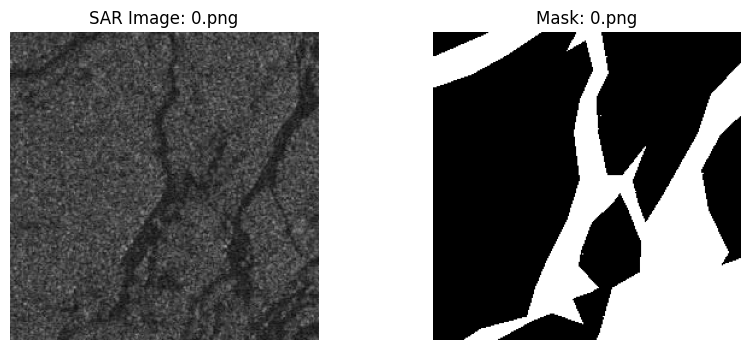

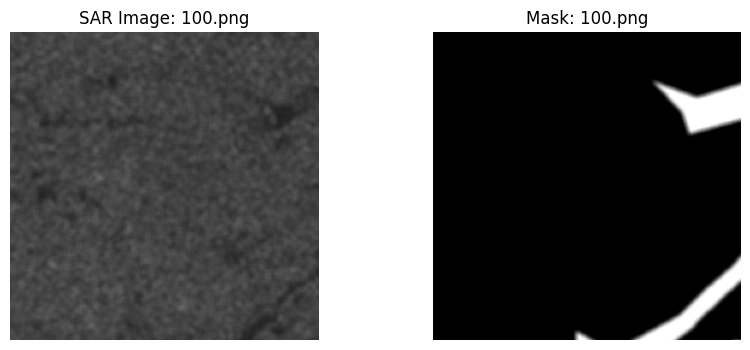

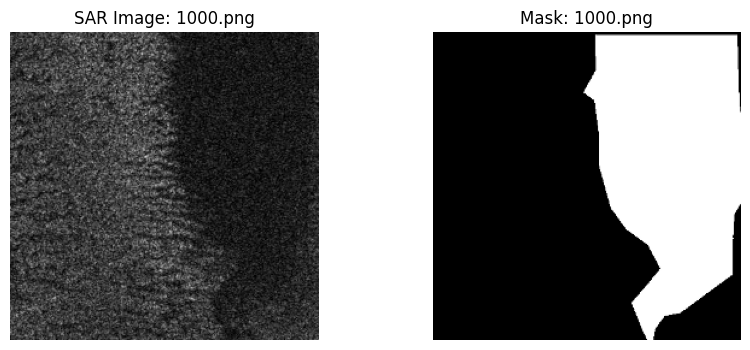

In [5]:
import matplotlib.pyplot as plt
from PIL import Image


sample_ids = ["0.png", "100.png", "1000.png"]

for filename in sample_ids:

    image_path = os.path.join(SENTINEL_IMAGE_PATH, filename)
    mask_path = os.path.join(SENTINEL_LABEL_PATH, filename)

    image = Image.open(image_path)
    mask = Image.open(mask_path)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"SAR Image: {filename}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Mask: {filename}")
    plt.axis("off")

    plt.show()

In [6]:
from PIL import Image
import numpy as np


sample_file = "0.png"

image = np.array(
    Image.open(os.path.join(SENTINEL_IMAGE_PATH, sample_file))
)

mask = np.array(
    Image.open(os.path.join(SENTINEL_LABEL_PATH, sample_file))
)

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Image min/max:", image.min(), image.max())

print("\nMask shape:", mask.shape)
print("Mask dtype:", mask.dtype)
print("Mask unique values:", np.unique(mask))

Image shape: (256, 256, 3)
Image dtype: uint8
Image min/max: 6 164

Mask shape: (256, 256, 3)
Mask dtype: uint8
Mask unique values: [  0 255]


In [7]:
import tensorflow as tf

IMG_SIZE = (256, 256)

def load_image_mask(image_path, mask_path):

    # Load image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)

    # Load mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.convert_image_dtype(mask, tf.float32)

    # Convert mask from 0/255 to 0/1
    mask = tf.cast(mask > 0.5, tf.float32)

    return image, mask

In [8]:
image_paths = []
mask_paths = []

for filename in sorted(os.listdir(SENTINEL_IMAGE_PATH)):
    image_path = os.path.join(SENTINEL_IMAGE_PATH, filename)
    mask_path = os.path.join(SENTINEL_LABEL_PATH, filename)

    if os.path.exists(mask_path):
        image_paths.append(image_path)
        mask_paths.append(mask_path)

print("Total image-mask pairs:", len(image_paths))

Total image-mask pairs: 3354


<h2>Training<h2>

In [9]:
from sklearn.model_selection import train_test_split

train_images, val_images, train_masks, val_masks = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.20,
    random_state=42
)

print("Training images:", len(train_images))
print("Validation images:", len(val_images))
print("Training masks:", len(train_masks))
print("Validation masks:", len(val_masks))

Training images: 2683
Validation images: 671
Training masks: 2683
Validation masks: 671


In [10]:
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_images, train_masks)
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_images, val_masks)
)

# Load and preprocess image + mask
train_dataset = train_dataset.map(
    load_image_mask,
    num_parallel_calls=AUTOTUNE
)

val_dataset = val_dataset.map(
    load_image_mask,
    num_parallel_calls=AUTOTUNE
)

# Shuffle only training data
train_dataset = train_dataset.shuffle(
    buffer_size=len(train_images),
    seed=42
)

# Create batches
train_dataset = train_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.batch(BATCH_SIZE)

# Optimize pipeline
train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)

print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


In [11]:
from tensorflow.keras import layers, Model

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x


def encoder_block(x, filters):
    features = conv_block(x, filters)
    pooled = layers.MaxPooling2D(pool_size=(2, 2))(features)
    return features, pooled


def decoder_block(x, skip, filters):
    x = layers.Conv2DTranspose(
        filters,
        kernel_size=2,
        strides=2,
        padding="same"
    )(x)

    x = layers.Concatenate()([x, skip])

    x = conv_block(x, filters)

    return x


# Input
inputs = layers.Input(shape=(256, 256, 3))

# Encoder
skip1, pool1 = encoder_block(inputs, 32)
skip2, pool2 = encoder_block(pool1, 64)
skip3, pool3 = encoder_block(pool2, 128)
skip4, pool4 = encoder_block(pool3, 256)

# Bottleneck
bottleneck = conv_block(pool4, 512)

# Decoder
decode1 = decoder_block(bottleneck, skip4, 256)
decode2 = decoder_block(decode1, skip3, 128)
decode3 = decoder_block(decode2, skip2, 64)
decode4 = decoder_block(decode3, skip1, 32)

# Output
outputs = layers.Conv2D(
    1,
    kernel_size=1,
    activation="sigmoid"
)(decode4)

unet = Model(inputs, outputs, name="U-Net")

unet.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_3[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_8[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │    524,544 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 7,760,097 (29.60 MB)

 Trainable params: 7,760,097 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
import tensorflow as tf


def dice_coefficient(y_true, y_pred):
    smooth = 1e-6

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_flat * y_pred_flat)

    dice = (
        (2.0 * intersection + smooth) /
        (
            tf.reduce_sum(y_true_flat)
            + tf.reduce_sum(y_pred_flat)
            + smooth
        )
    )

    return dice


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)


def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)

    # Average BCE across all pixels
    bce = tf.reduce_mean(bce)

    return bce + dice_loss(y_true, y_pred)

In [13]:
unet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[
        dice_coefficient,
        tf.keras.metrics.BinaryIoU(
            target_class_ids=[1],
            threshold=0.5
        )
    ]
)

print("U-Net compiled successfully.")

U-Net compiled successfully.


In [14]:
checkpoint_path='/content/drive/MyDrive/MARIS/best_unet_oilspill.keras'

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True
    )
]

history_unet = unet.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 138s 272ms/step - binary_io_u: 0.4816 - dice_coefficient: 0.5852 - loss: 0.8238 - val_binary_io_u: 0.6056 - val_dice_coefficient: 0.6658 - val_loss: 0.6902
Epoch 2/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 73s 176ms/step - binary_io_u: 0.6611 - dice_coefficient: 0.7192 - loss: 0.6042 - val_binary_io_u: 0.6628 - val_dice_coefficient: 0.7204 - val_loss: 0.5692
Epoch 3/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 75s 174ms/step - binary_io_u: 0.6811 - dice_coefficient: 0.7486 - loss: 0.5432 - val_binary_io_u: 0.6793 - val_dice_coefficient: 0.7271 - val_loss: 0.5316
Epoch 4/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 76s 178ms/step - binary_io_u: 0.6928 - dice_coefficient: 0.7580 - loss: 0.5187 - val_binary_io_u: 0.6916 - val_dice_coefficient: 0.7726 - val_loss: 0.5012
Epoch 5/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 74s 175ms/step - binary_io_u: 0.7009 - dice_coefficient: 0.7682 - loss: 0.4963 - val_binary_io_u: 0.7076 - val_dice_coefficient: 0.7744 - val_loss: 0.4641
Epoch 6/20
336/336 ━━━━━

In [16]:
unet = tf.keras.models.load_model(
    "/content/drive/MyDrive/MARIS/best_unet_oilspill.keras",
    custom_objects={
        "combined_loss": combined_loss,
        "dice_coefficient": dice_coefficient
    }
)

print("U-Net loaded successfully!")

U-Net loaded successfully!


<h2>Evaluating<h2>

In [17]:
import os

TEST_IMAGE_PATH = "/content/drive/MyDrive/oilspill_detect.ai/segmentation/dataset/test/sentinel/image"
TEST_LABEL_PATH = "/content/drive/MyDrive/oilspill_detect.ai/segmentation/dataset/test/sentinel/label"

test_image_paths = []
test_mask_paths = []

for filename in sorted(os.listdir(TEST_IMAGE_PATH)):

    image_path = os.path.join(TEST_IMAGE_PATH, filename)
    mask_path = os.path.join(TEST_LABEL_PATH, filename)

    if os.path.exists(mask_path):
        test_image_paths.append(image_path)
        test_mask_paths.append(mask_path)

print("Test images:", len(test_image_paths))
print("Test masks:", len(test_mask_paths))

Test images: 839
Test masks: 839


In [18]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE


def load_test_image_mask(image_path, mask_path):

    # Load image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.convert_image_dtype(
        image, tf.float32
    )

    # Load mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.convert_image_dtype(
        mask, tf.float32
    )

    # Convert mask to binary
    mask = tf.cast(mask > 0.5, tf.float32)

    return image, mask


test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_image_paths, test_mask_paths)
)

test_dataset = test_dataset.map(
    load_test_image_mask,
    num_parallel_calls=AUTOTUNE
)

test_dataset = test_dataset.batch(BATCH_SIZE)

test_dataset = test_dataset.prefetch(AUTOTUNE)


print("Test dataset ready!")

Test dataset ready!


In [19]:
test_results = unet.evaluate(
    test_dataset,
    verbose=1
)

print("\nTest Results:")
for name, value in zip(unet.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

53/53 ━━━━━━━━━━━━━━━━━━━━ 211s 3s/step - binary_io_u: 0.7293 - dice_coefficient: 0.8087 - loss: 0.4767

Test Results:
loss: 0.4767
compile_metrics: 0.8087


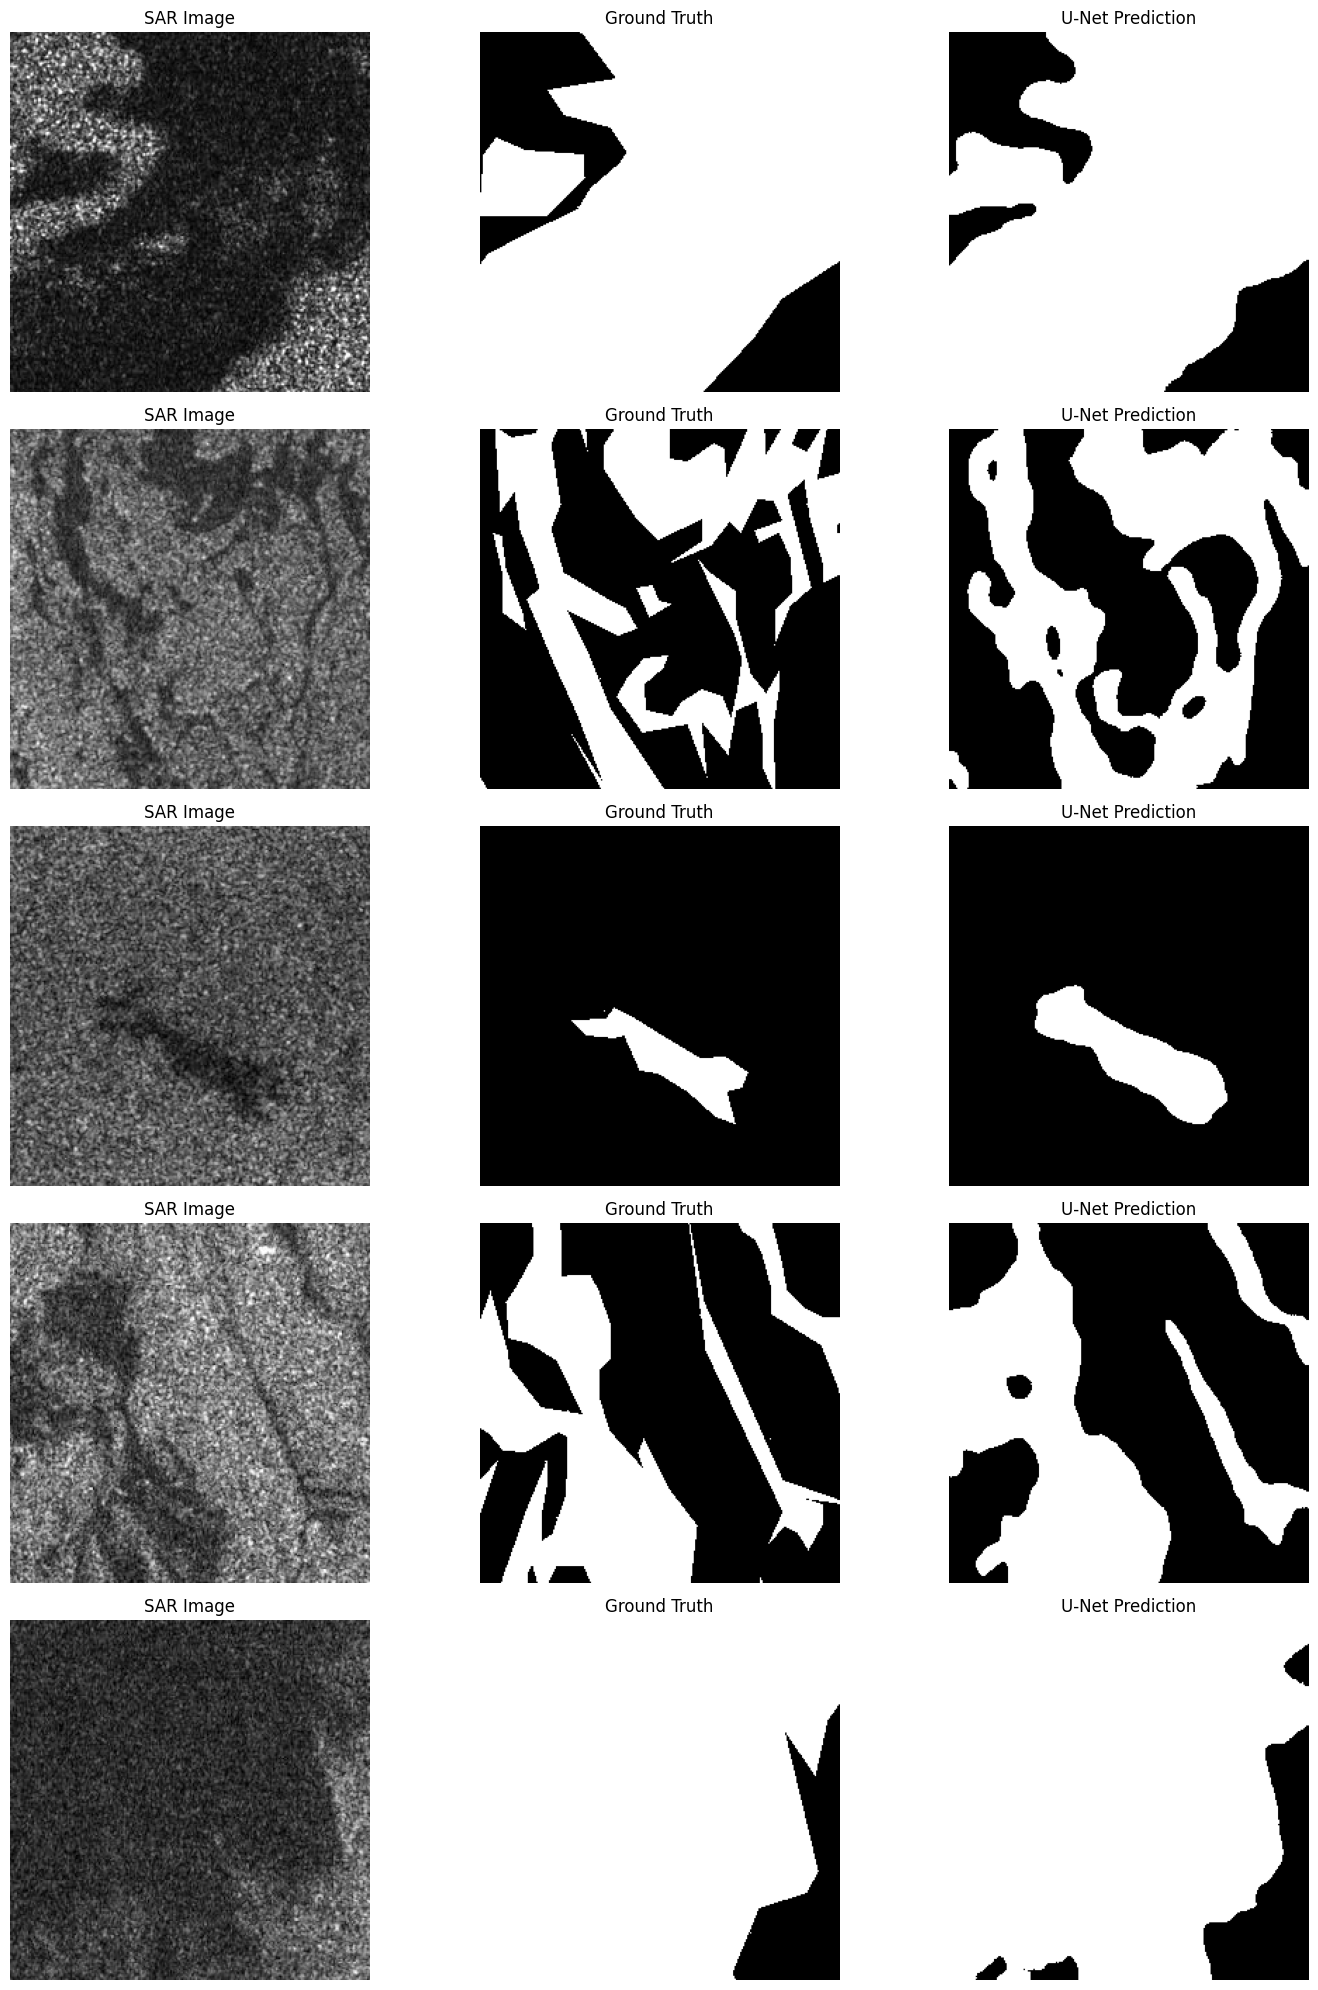

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Take 5 different batches from the test dataset
test_batches = list(test_dataset.take(5))

plt.figure(figsize=(15, 20))

for i, (images, true_masks) in enumerate(test_batches):

    # Take a different image from each batch
    image = images[0].numpy()
    true_mask = true_masks[0].numpy()

    # Prediction
    prediction = unet.predict(
        images[:1],
        verbose=0
    )[0]

    # Convert probability to binary mask
    predicted_mask = (
        prediction > 0.5
    ).astype(np.float32)

    # SAR image
    plt.subplot(5, 3, i * 3 + 1)
    plt.imshow(image)
    plt.title("SAR Image")
    plt.axis("off")

    # Ground truth
    plt.subplot(5, 3, i * 3 + 2)
    plt.imshow(
        true_mask.squeeze(),
        cmap="gray"
    )
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(5, 3, i * 3 + 3)
    plt.imshow(
        predicted_mask.squeeze(),
        cmap="gray"
    )
    plt.title("U-Net Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

all_true = []
all_pred = []

for images, true_masks in test_dataset:

    # Predict probabilities
    predictions = unet.predict(
        images,
        verbose=0
    )

    # Convert probabilities to binary masks
    predictions = (predictions > 0.5).astype(np.uint8)
    true_masks = true_masks.numpy().astype(np.uint8)

    # Flatten pixels
    all_true.extend(true_masks.flatten())
    all_pred.extend(predictions.flatten())


all_true = np.array(all_true)
all_pred = np.array(all_pred)


precision = precision_score(
    all_true,
    all_pred,
    zero_division=0
)

recall = recall_score(
    all_true,
    all_pred,
    zero_division=0
)

f1 = f1_score(
    all_true,
    all_pred,
    zero_division=0
)


print("Pixel-level Evaluation")
print("----------------------")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Pixel-level Evaluation
----------------------
Precision : 0.8050
Recall    : 0.8858
F1 Score  : 0.8435
